# Limpieza, transformación y preparación de datos con Python

## Clase de Analítica de Datos

### Temas

- Limpieza y depuración
- Variables cuantitativas y categóricas
- Datos faltantes e imputación
- Valores atípicos
- Normalidad y gráficos Q-Q
- Transformaciones logarítmicas y de potencia
- Normalización y estandarización
- Codificación ordinal
- One-Hot Encoding y dumificación
- Categorías desconocidas
- Data leakage
- Pipeline y ColumnTransformer

> **Idea central:** limpiar datos no es “borrar lo raro”, sino comprender, diagnosticar, justificar y documentar cada transformación.

# Objetivos de aprendizaje

Al finalizar la clase, el estudiante podrá:

1. diferenciar limpieza, depuración y transformación;
2. identificar tipos de variables;
3. diagnosticar faltantes, duplicados e inconsistencias;
4. detectar outliers mediante IQR y puntaje z;
5. decidir cómo tratar faltantes y valores atípicos;
6. interpretar normalidad e identificarla con gráficos Q-Q;
7. diferenciar transformaciones de forma y escalamiento;
8. aplicar logaritmo, Min-Max, StandardScaler y Yeo-Johnson;
9. diferenciar categóricas nominales y ordinales;
10. aplicar dumificación y codificación ordinal;
11. evitar fuga de información;
12. construir un flujo reproducible de preprocesamiento.

## Parte I. Auditoría y comprensión
1. Bases de trabajo
2. Tipos de variables
3. Auditoría inicial
4. Duplicados y consistencia

## Parte II. Calidad
5. Faltantes
6. Imputación
7. Outliers
8. Tratamiento responsable

## Parte III. Distribuciones
9. Normalidad
10. Q-Q plots
11. Logaritmo y potencia
12. Min-Max y estandarización

## Parte IV. Categóricas
13. Nominales y ordinales
14. Ordinal Encoding
15. One-Hot / dummies
16. Alta cardinalidad

## Parte V. Flujo profesional
17. Train/test
18. Leakage
19. Pipeline
20. Caso integrador y ejercicios

# 1. Preparación del entorno

In [1]:
%mamba install numpy pandas matplotlib seaborn scikit-learn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 2.100 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.7.22  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.4.9      pyhd8ed1ab_0         conda-forge
+ idna                3.18       pyhcf101f3_0         conda-forge
+ joblib              1.5.3      py313h1804a44_3      emscripten-forge-4x
+ narwhals            2.24.0     pyhcf101f3_0         conda-forge
+ pandas              3.0.5      np23py313h1e705a5_0  emscripten-forge-4x
+ patsy               1.0.2      py313h1804a44_3      emscripten-forge-4x
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ p

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy import stats

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    PowerTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    LabelEncoder
)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Entorno preparado.")

Entorno preparado.


## 1.1 Localización de archivos

El notebook busca los datos en la carpeta actual y, si se ejecuta en este entorno, también en `/mnt/data`.

In [3]:
def buscar_archivo(nombre):
    candidatos = [
        Path(nombre),
        Path.cwd() / nombre,
        Path("/mnt/data") / nombre
    ]
    for ruta in candidatos:
        if ruta.exists():
            return ruta
    raise FileNotFoundError(
        f"No se encontró {nombre}. Colóquelo junto al notebook."
    )

# 2. Bases de datos de trabajo

## Titanic — `train.csv`

Cada fila representa un pasajero. La base incluye:

- `Survived`: objetivo binario;  Sobrevivio o no? 0-1
- `Pclass`: clase del pasajero;
- `Name`: Nombre del pasajero
- `Sex`; Es hombre o mujer?
- `Age`; Edad del pasajero
- `SibSp`: Número de hermanos/cónyuges a bordo del Titanic
- `Parch`: Número de padres/hijos a bordo del Titanic
- `Ticket`: Número de boleto
- `Fare`; Tarifa del pasajero
- `Embarked`: Puerto de embarque.


Es especialmente útil para estudiar faltantes, outliers, imputación, variables mixtas y codificación.

## Viviendas — `train_cat.csv`

Contiene variables numéricas y categóricas de propiedades. Usaremos especialmente:

- `ExterQual`;
- `ExterCond`;
- `SaleCondition`;
- `MSSubClass`;
- `SalePrice`.

Es útil para distinguir categorías nominales y ordinales.

In [4]:
ruta_titanic = buscar_archivo("train.csv")
ruta_viviendas = buscar_archivo("train_cat.csv")

titanic_raw = pd.read_csv(ruta_titanic)
viviendas_raw = pd.read_csv(ruta_viviendas)

print("Titanic:", titanic_raw.shape)
print("Viviendas:", viviendas_raw.shape)

Titanic: (891, 12)
Viviendas: (2302, 81)


In [5]:
titanic_raw.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


In [6]:
viviendas_raw[
    ["MSSubClass", "ExterQual", "ExterCond", "SaleCondition", "SalePrice"]
].head()

,MSSubClass,ExterQual,ExterCond,SaleCondition,SalePrice
0,20,Gd,TA,Normal,"245,350.000"
1,90,TA,TA,Normal,"190,000.000"
2,80,TA,TA,Normal,"180,000.000"
3,20,TA,TA,Normal,"128,000.000"
4,30,TA,Fa,Abnorml,"67,000.000"


# PARTE I. COMPRENDER Y AUDITAR LOS DATOS

# 3. ¿Qué es la limpieza de datos?

La **limpieza de datos** identifica y trata problemas que pueden afectar la validez, interpretación o uso posterior de una base.

Un flujo típico es:

$$
\text{dato bruto}
\longrightarrow
\text{diagnóstico}
\longrightarrow
\text{decisión}
\longrightarrow
\text{dato preparado}.
$$

Puede incluir:

- valores faltantes;
- duplicados;
- tipos incorrectos;
- valores imposibles;
- categorías inconsistentes;
- valores atípicos;
- variables irrelevantes;
- transformaciones.

<center>
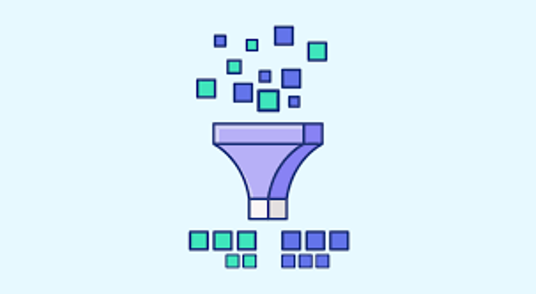
</center>

## UnderFitting vs OverFitting

- Underfit: El modelo es demasiado simple y no captura la relación en los datos. Mucho BIAS.
- Overfit: El modelo se ajusta en exceso a los datos de entrenamiento y por lo tanto, no generaliza bien sobre nuevos datos. Mucha Variance.

<center>
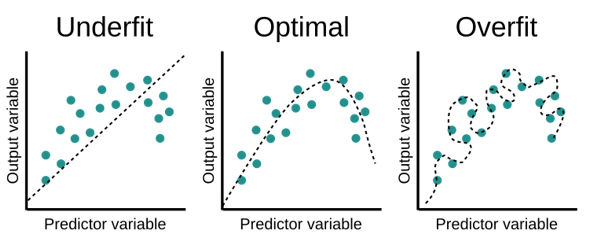
</center>

## Bias vs Variance

- Bias (Sesgo) : Es el Error sistemático en las predicciones del modelo.
- Variance (Varianza) : Es la sensibilidad del modelo a pequeñas fluctuaciones en la data de entrenamiento. Si es muy elevada el modelo sobreajusta.

<center>
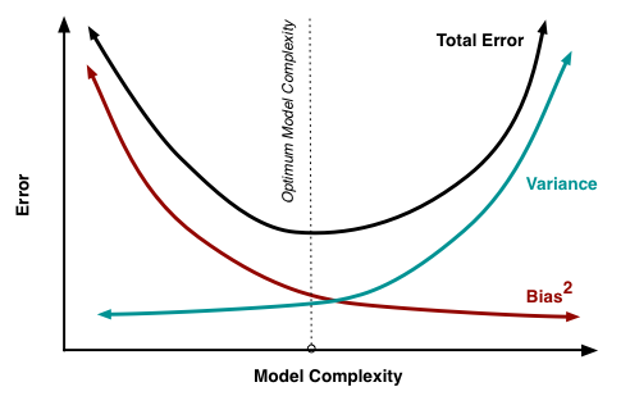
</center>

### ¿Como las corregimos?

#### Bias:

- Aumentando la complejidad del modelo.
- Añadiendo nuevas características.

#### Variance:
- Añadir más datos de entrenamiento (Si se puede).
- Simplificar el modelo.
- Utilizar un método de reducción de características (PCA).

## Outliers

- Son observaciones distantes del resto.
- Puede deberse a variabilidad propia de los datos o a errores de medida.
- No hay una definición matemática de que es un outlier pero hay 2 métodos para identificarlos:
  - 3* STD
  - + 1.5 IQR

<center>
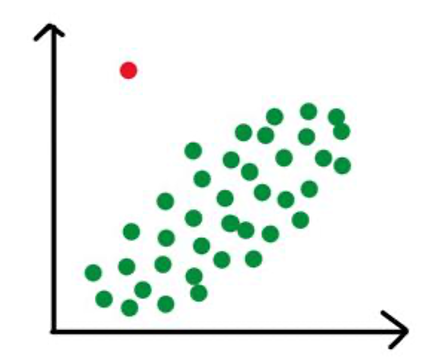
</center>

## Missing Values

- Son atributos para los cuales no hay información en una observación.
- Cómo tratarlos?
  - Eliminarlos (Sencillo pero perdemos info)
  - Sustituir por valor estadístico (Media, mediana..)
  - Emplear un modelo para rellenar esos valores.


<center>
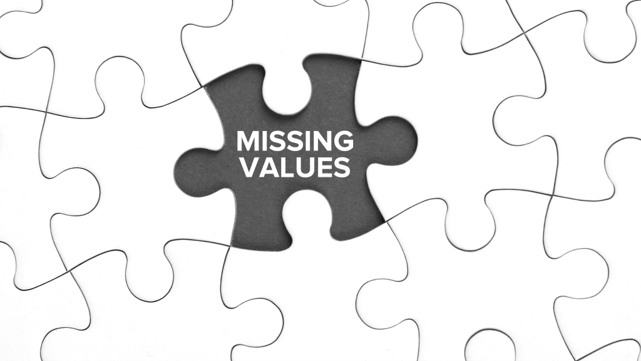
</center>

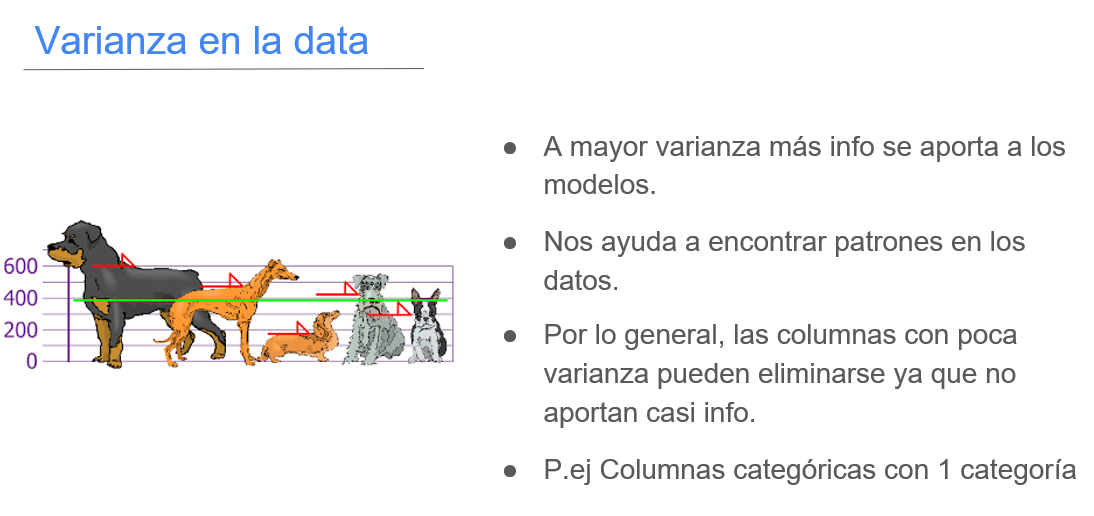

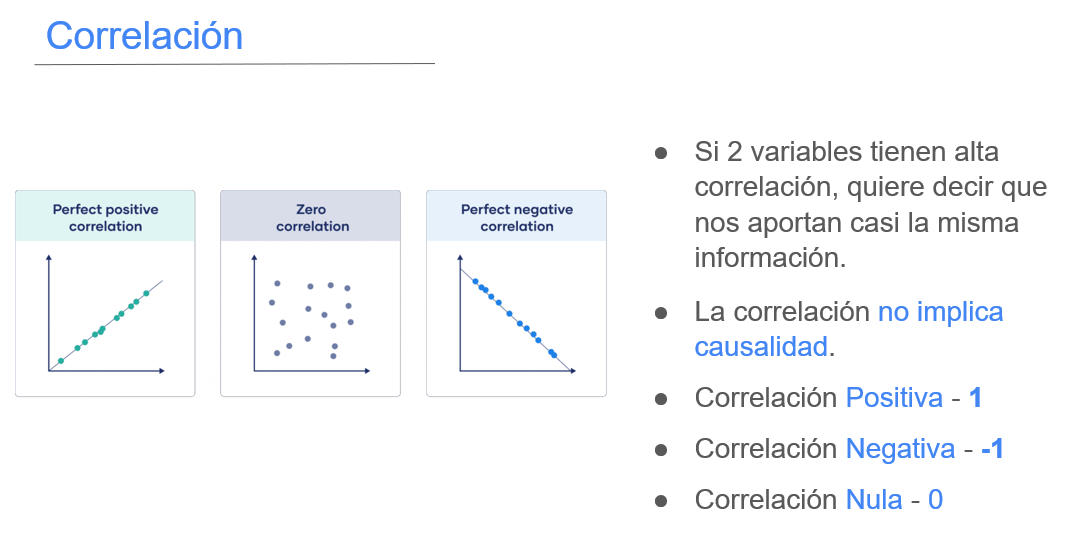

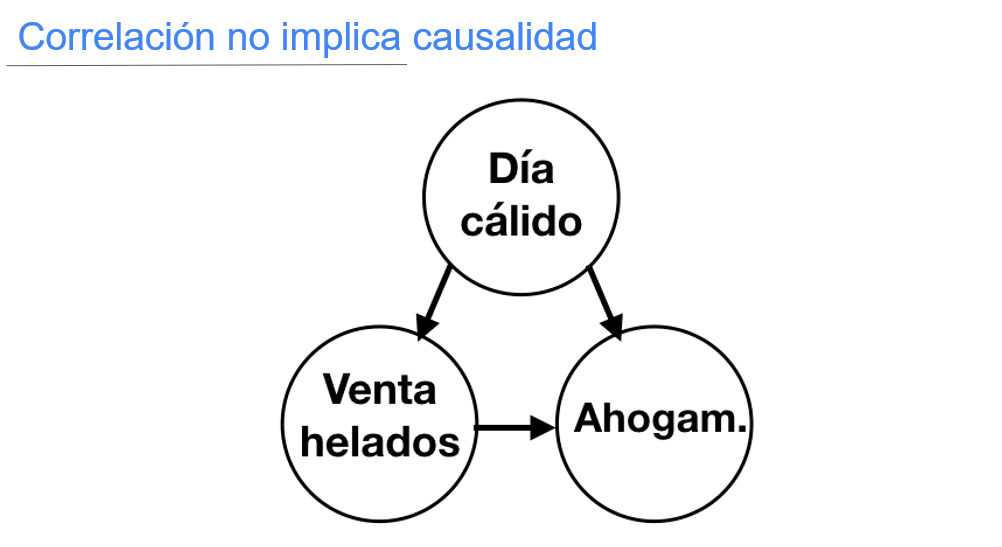

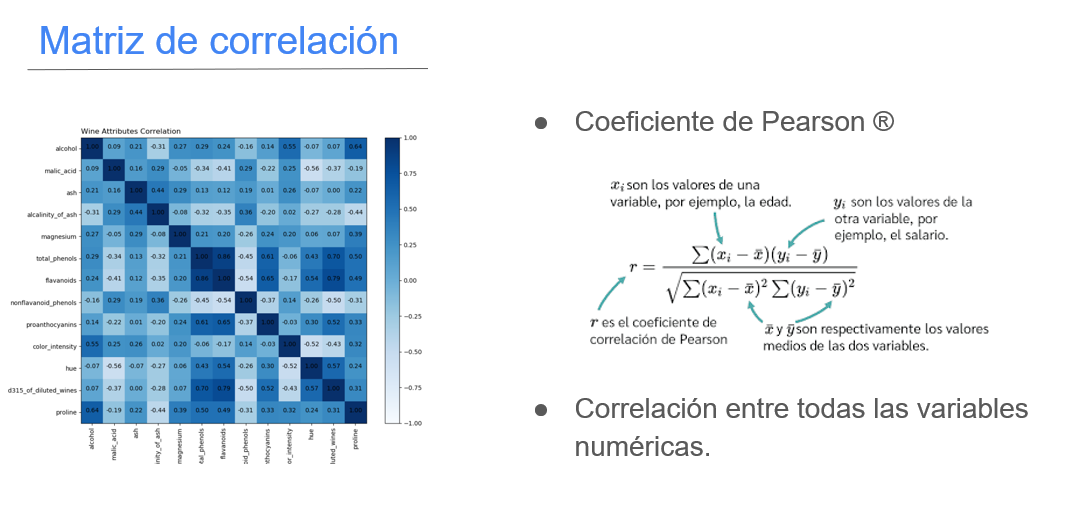

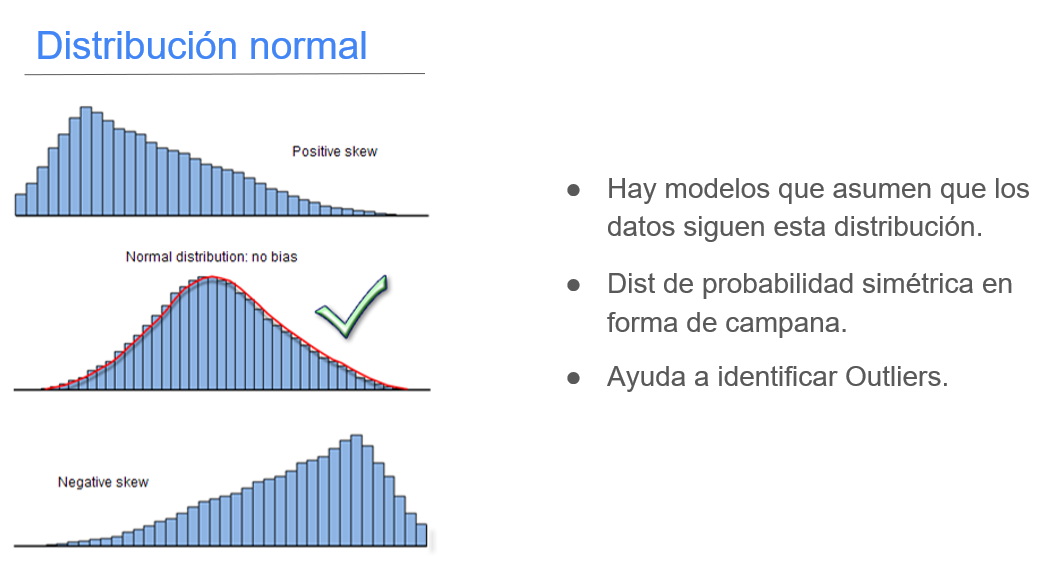

# Transformación

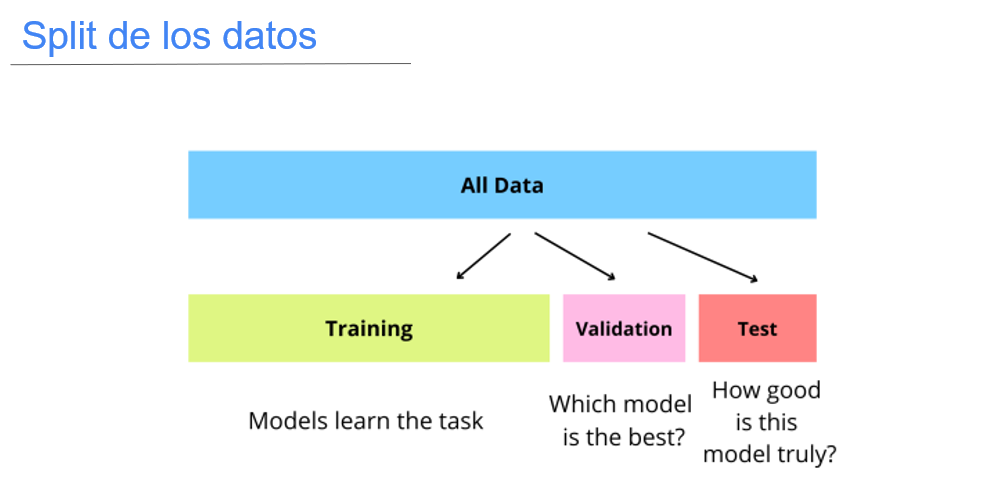

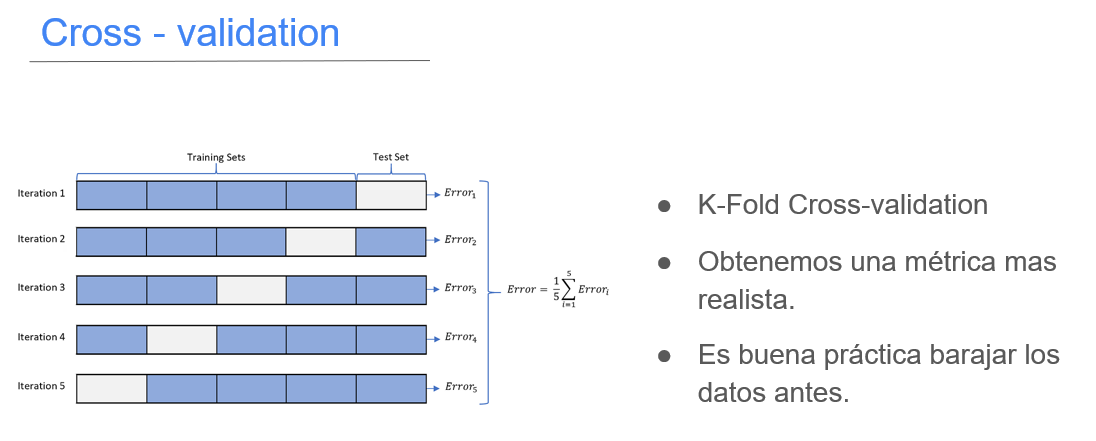

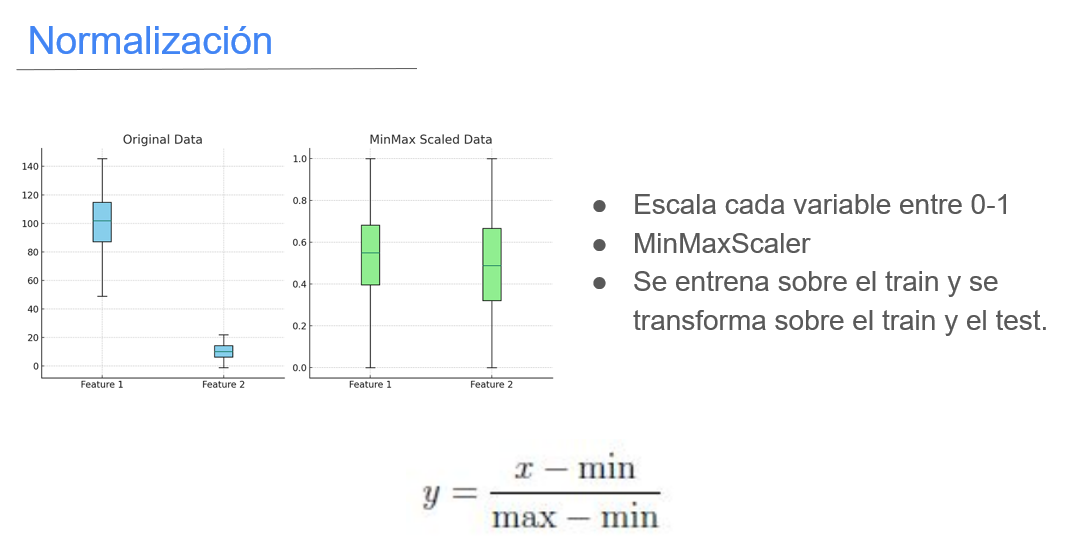

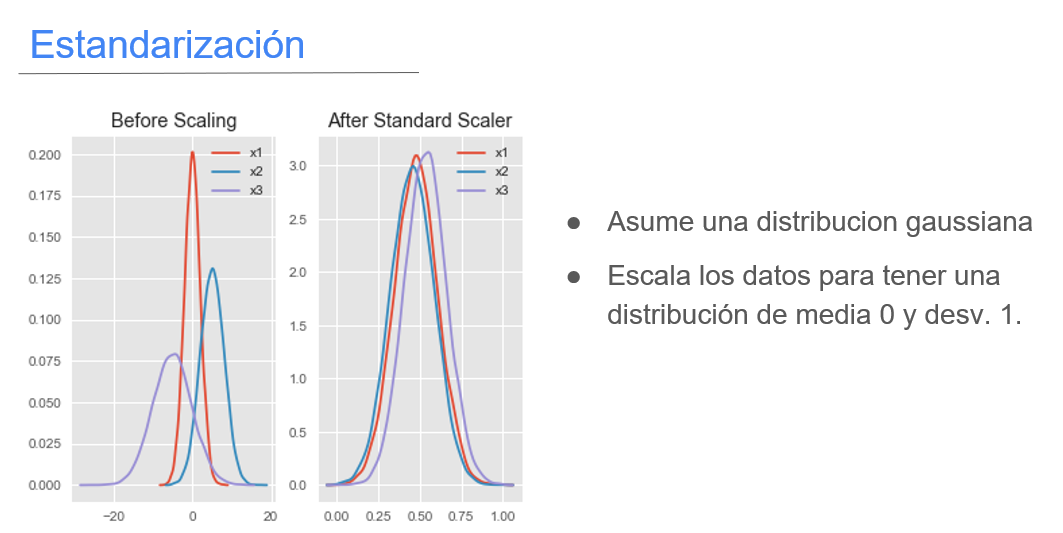

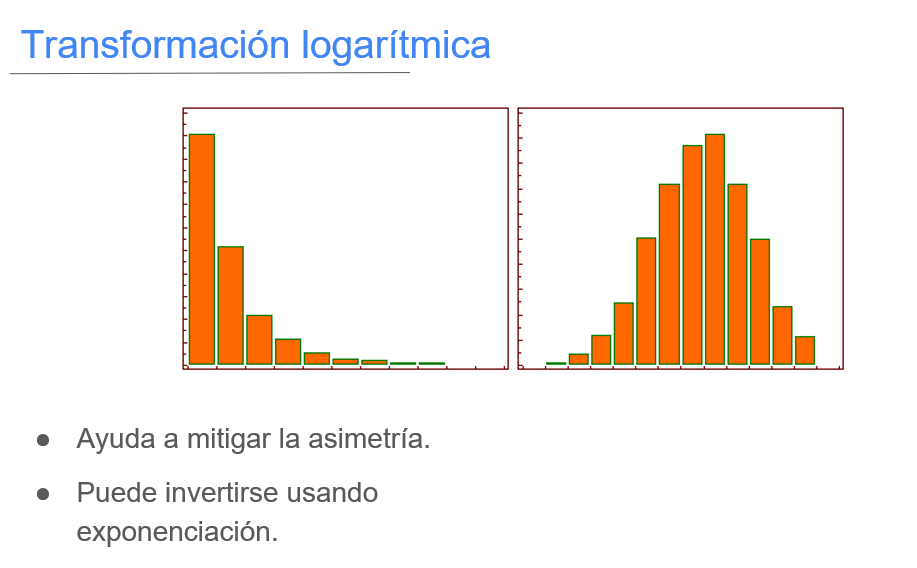

## 3.1 Limpieza, depuración y transformación

### Limpieza
Corrige problemas de calidad.

Ejemplos:

- imputar una edad faltante;
- corregir espacios en una categoría;
- eliminar un duplicado real.

### Depuración
Reduce o reorganiza información para dejar una base útil.

Ejemplos:

- retirar identificadores;
- revisar columnas constantes;
- controlar alta cardinalidad.

### Transformación
Cambia la representación.

Ejemplos:

$$
X\longrightarrow \log(1+X),
$$

$$
X\longrightarrow \frac{X-\bar X}{s},
$$

o crear variables dummy.

# 4. Tipos de variables

## Cuantitativas

Representan cantidades.

### Discretas
Generalmente provienen de conteos.

### Continuas
Pueden tomar valores en un intervalo.

## Categóricas

### Nominales
No poseen un orden intrínseco.

### Ordinales
Sus categorías sí poseen un orden.

Ejemplo:

$$
\text{Fa}<\text{TA}<\text{Gd}<\text{Ex}.
$$

## 4.1 El `dtype` no determina el tipo estadístico

`Pclass` está almacenada como entero, pero representa clases.

`MSSubClass` también está almacenada numéricamente, aunque sus números funcionan como códigos de categorías.

Por tanto:

> `int64` no significa automáticamente “variable cuantitativa”.

In [7]:
titanic_raw.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [8]:
print("Pclass:", sorted(titanic_raw["Pclass"].unique()))
print("MSSubClass - categorías:", viviendas_raw["MSSubClass"].nunique())

Pclass: [np.int64(1), np.int64(2), np.int64(3)]
MSSubClass - categorías: 16


## 4.2 Identificadores

Un identificador puede ser numérico sin representar una magnitud.

Ejemplos:

- `PassengerId`;
- `Id`;
- número de cliente.

No tiene sentido interpretar su media o desviación como características del fenómeno.

# 5. Descripción inicial

Antes de transformar:

1. dimensiones;
2. nombres;
3. tipos;
4. valores únicos;
5. faltantes;
6. duplicados;
7. reglas de validez;
8. distribuciones.

In [9]:
print("Dimensiones:", titanic_raw.shape)
titanic_raw.info()

Dimensiones: (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 66.2 KB


In [10]:
titanic_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.000,446.000,257.354,1.000,223.500,446.000,668.500,891.000
Survived,891.000,0.384,0.487,0.000,0.000,0.000,1.000,1.000
Pclass,891.000,2.309,0.836,1.000,2.000,3.000,3.000,3.000
Age,714.000,29.699,14.526,0.420,20.125,28.000,38.000,80.000
SibSp,891.000,0.523,1.103,0.000,0.000,0.000,1.000,8.000
Parch,891.000,0.382,0.806,0.000,0.000,0.000,0.000,6.000
Fare,891.000,32.204,49.693,0.000,7.910,14.454,31.000,512.329


In [16]:
titanic_raw.describe(include=['O']).T

/tmp/xpython_42/2732017655.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  titanic_raw.describe(include=['O']).T


,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


In [17]:
titanic_raw.nunique().sort_values()

Survived         2
Sex              2
Pclass           3
Embarked         3
SibSp            7
Parch            7
Age             88
Cabin          147
Fare           248
Ticket         681
PassengerId    891
Name           891
dtype: int64

## 5.1 Reporte 

In [18]:
def reporte_calidad(df):
    r = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_unicos": df.nunique(dropna=True),
        "faltantes": df.isna().sum(),
        "pct_faltantes": df.isna().mean() * 100
    })
    r["pct_faltantes"] = r["pct_faltantes"].round(2)
    return r.sort_values("pct_faltantes", ascending=False)

reporte_calidad(titanic_raw)

,dtype,n_unicos,faltantes,pct_faltantes
Cabin,str,147,687,77.100
Age,float64,88,177,19.870
Embarked,str,3,2,0.220
PassengerId,int64,891,0,0.000
Survived,int64,2,0,0.000
Pclass,int64,3,0,0.000
Name,str,891,0,0.000
Sex,str,2,0,0.000
SibSp,int64,7,0,0.000
Parch,int64,7,0,0.000


# 6. Duplicados

Un registro repetido puede ser:

- un error de carga;
- una concatenación repetida;
- o una observación legítimamente repetida.

Primero se diagnostica; después se decide.

In [19]:
print("Duplicados exactos:", titanic_raw.duplicated().sum())

Duplicados exactos: 0


## 6.1 Corrección de tipo

Para tratar `Pclass` como categoría:

```python
df["Pclass"] = df["Pclass"].astype("category")
```

In [22]:
titanic = titanic_raw.copy()
titanic["Pclass"] = titanic["Pclass"].astype("category")
titanic[["Pclass"]].dtypes

Pclass    category
dtype: object

## 6.2 Limpieza de texto

En bases reales conviene revisar:

- espacios;
- mayúsculas/minúsculas;
- tildes;
- abreviaturas;
- categorías equivalentes.

Patrón general:

```python
df["categoria"] = (
    df["categoria"]
    .str.strip()
    .str.lower()
)
```

In [23]:
for col in ["Sex", "Embarked"]:
    print("\n", col)
    print(titanic_raw[col].value_counts(dropna=False))


 Sex
Sex
male      577
female    314
Name: count, dtype: int64

 Embarked
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64


# PARTE II. DATOS FALTANTES Y VALORES ATÍPICOS

# 7. Datos faltantes

Un valor faltante indica ausencia de información.

Si una columna contiene \(m\) valores faltantes entre \(n\) observaciones:

$$
\%NA
=
\frac{m}{n}\times100.
$$

In [26]:
faltantes = pd.DataFrame({
    "faltantes": titanic_raw.isna().sum(),
    "porcentaje": titanic_raw.isna().mean() * 100
})
faltantes["porcentaje"] = faltantes["porcentaje"].round(2)
faltantes.sort_values("porcentaje", ascending=False)

,faltantes,porcentaje
Cabin,687,77.100
Age,177,19.870
Embarked,2,0.220
PassengerId,0,0.000
Survived,0,0.000
Pclass,0,0.000
Name,0,0.000
Sex,0,0.000
SibSp,0,0.000
Parch,0,0.000


## 7.1 Visualización del patrón de ausencia

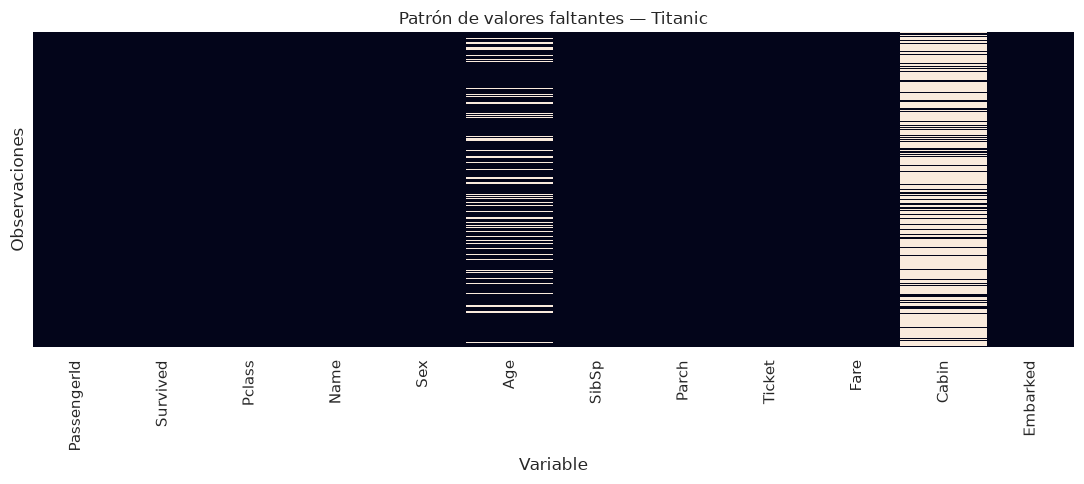

In [25]:
plt.figure(figsize=(11, 5))
sns.heatmap(
    titanic_raw.isna(),
    cbar=False,
    yticklabels=False
)
plt.title("Patrón de valores faltantes — Titanic")
plt.xlabel("Variable")
plt.ylabel("Observaciones")
plt.tight_layout()
plt.show()

## 7.2 Mecanismos de ausencia

### MCAR
La ausencia no depende de variables observadas ni no observadas.

### MAR
La ausencia puede explicarse mediante otras variables observadas.

### MNAR
La ausencia depende del propio valor no observado o de procesos no medidos.

Esto importa porque:

> imputar implica asumir algo sobre el mecanismo que produjo la ausencia.

# 8. ¿Eliminar o imputar?

Opciones:

1. eliminar filas;
2. eliminar columnas;
3. media;
4. mediana;
5. moda;
6. categoría `Unknown`;
7. imputación por vecinos o modelos;
8. indicador de ausencia.

## 8.1 Eliminar filas

In [27]:
print("Forma original:", titanic_raw.shape)
print("Después de dropna():", titanic_raw.dropna().shape)

Forma original: (891, 12)
Después de dropna(): (183, 12)


Eliminar toda fila con algún faltante sería muy agresivo en Titanic debido, especialmente, a `Cabin`.

## 8.2 La ausencia puede ser informativa

In [28]:
titanic["HasCabin"] = titanic_raw["Cabin"].notna().astype(int)

titanic.groupby("HasCabin")["Survived"].agg(
    cantidad="count",
    tasa_supervivencia="mean"
)

,cantidad,tasa_supervivencia
HasCabin,,
0,687,0.300
1,204,0.667


En lugar de descartar inmediatamente `Cabin`, creamos:

$$
HasCabin=
\begin{cases}
1,&\text{cabina observada}\\
0,&\text{cabina faltante}
\end{cases}
$$

La propia ausencia puede contener señal.

# 9. Imputación numérica

## Media

$$
\bar{x}
=
\frac{1}{n}\sum_{i=1}^{n}x_i.
$$

Imputar por media:

$$
x_i^{miss}\leftarrow \bar{x}_{obs}.
$$

Es sencillo, pero puede:

- reducir varianza;
- crear concentraciones artificiales;
- ser sensible a extremos.

## 9.1 Mediana

La mediana es más robusta frente a valores extremos y asimetría.

Para `Age` compararemos ambas.

In [29]:
age_obs = titanic_raw["Age"].dropna()

print("Media:", age_obs.mean())
print("Mediana:", age_obs.median())
print("Nulos:", titanic_raw["Age"].isna().sum())

Media: 29.69911764705882
Mediana: 28.0
Nulos: 177


In [30]:
imp_mediana = SimpleImputer(strategy="median")

age_imp_mediana = imp_mediana.fit_transform(
    titanic_raw[["Age"]]
).ravel()

print("Mediana utilizada:", imp_mediana.statistics_[0])
print("Nulos después:", np.isnan(age_imp_mediana).sum())

Mediana utilizada: 28.0
Nulos después: 0


## 9.2 Efecto sobre la distribución

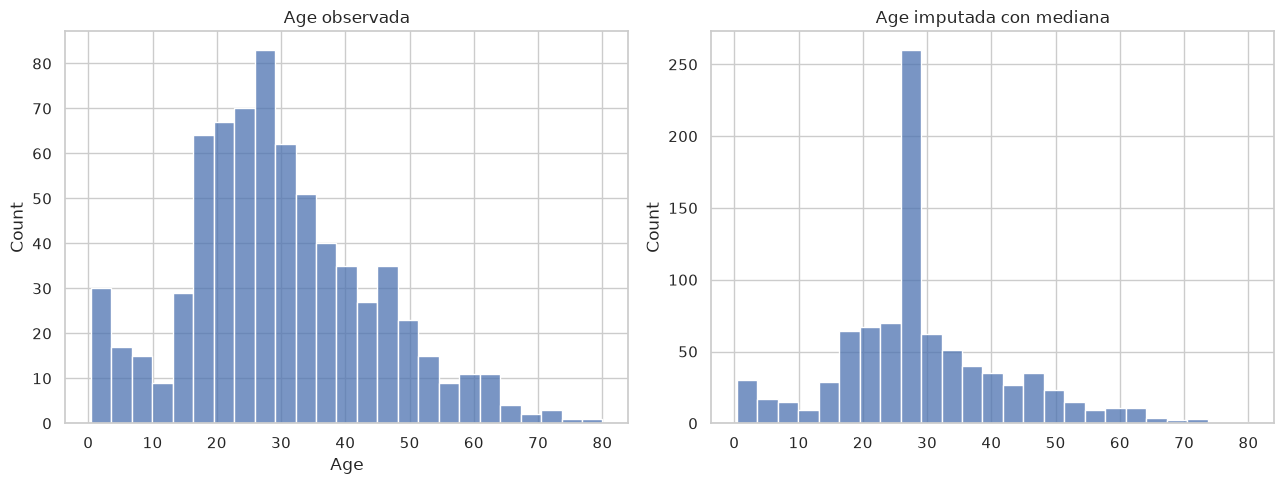

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(age_obs, bins=25, ax=axes[0])
axes[0].set_title("Age observada")

sns.histplot(age_imp_mediana, bins=25, ax=axes[1])
axes[1].set_title("Age imputada con mediana")

plt.tight_layout()
plt.show()

In [32]:
pd.DataFrame({
    "Antes": [
        age_obs.mean(),
        age_obs.std(),
        age_obs.var()
    ],
    "Después": [
        age_imp_mediana.mean(),
        age_imp_mediana.std(ddof=1),
        age_imp_mediana.var(ddof=1)
    ]
}, index=["Media", "Desviación", "Varianza"])

,Antes,Después
Media,29.699,29.362
Desviación,14.526,13.020
Varianza,211.019,169.512


La imputación simple no recupera los valores verdaderos; únicamente crea una representación completa de la base.

Por eso se debe documentar.

## 9.3 Imputación contextual por grupos

Podemos aprovechar otras variables:

$$
\widetilde{Age}_{g}
=
\operatorname{Mediana}
(Age\mid Sex,Pclass).
$$

In [33]:
medianas_age = (
    titanic_raw
    .groupby(["Sex", "Pclass"])["Age"]
    .median()
)

medianas_age

Sex     Pclass
female  1        35.000
        2        28.000
        3        21.500
male    1        40.000
        2        30.000
        3        25.000
Name: Age, dtype: float64

In [34]:
titanic["Age_group_imputed"] = (
    titanic_raw
    .groupby(["Sex", "Pclass"])["Age"]
    .transform(lambda s: s.fillna(s.median()))
)

titanic["Age_group_imputed"] = (
    titanic["Age_group_imputed"]
    .fillna(titanic_raw["Age"].median())
)

print(
    "Nulos restantes:",
    titanic["Age_group_imputed"].isna().sum()
)

Nulos restantes: 0


# 10. Imputación categórica

Para categorías puede utilizarse:

### Moda

$$
\operatorname{Moda}(X)
=
\arg\max_c f(c).
$$

### Categoría explícita

```text
Unknown
```

La segunda opción conserva la información de que el valor originalmente no estaba disponible.

In [35]:
titanic_raw["Embarked"].value_counts(dropna=False)

Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

In [36]:
imp_moda = SimpleImputer(strategy="most_frequent")
emb_moda = imp_moda.fit_transform(
    titanic_raw[["Embarked"]]
).ravel()

print("Moda usada:", imp_moda.statistics_[0])

Moda usada: S


In [37]:
imp_unknown = SimpleImputer(
    strategy="constant",
    fill_value="Unknown"
)

emb_unknown = imp_unknown.fit_transform(
    titanic_raw[["Embarked"]]
).ravel()

pd.Series(emb_unknown).value_counts()

S          644
C          168
Q           77
Unknown      2
Name: count, dtype: int64

# 11. Imputación por vecinos

`KNNImputer` estima un faltante a partir de observaciones cercanas.

Conceptualmente:

$$
\widehat{x}_{ij}
=
\frac{1}{k}
\sum_{\ell\in N_k(i)}x_{\ell j}.
$$

No es automáticamente superior. Su utilidad depende de que la noción de distancia sea informativa.

In [38]:
datos_knn = titanic_raw[
    ["Age", "Fare", "SibSp", "Parch"]
].copy()

knn = KNNImputer(n_neighbors=5)

knn_df = pd.DataFrame(
    knn.fit_transform(datos_knn),
    columns=datos_knn.columns
)

knn_df.isna().sum()

Age      0
Fare     0
SibSp    0
Parch    0
dtype: int64

# 12. Valores atípicos (*outliers*)

Un valor atípico es una observación alejada del patrón general.

Puede deberse a:

- variabilidad real;
- error de digitación;
- error de medición;
- evento excepcional;
- mezcla de subpoblaciones;
- fraude.

Por tanto:

$$
\boxed{\text{outlier} \neq \text{error}}
$$

## 12.1 Inspección gráfica

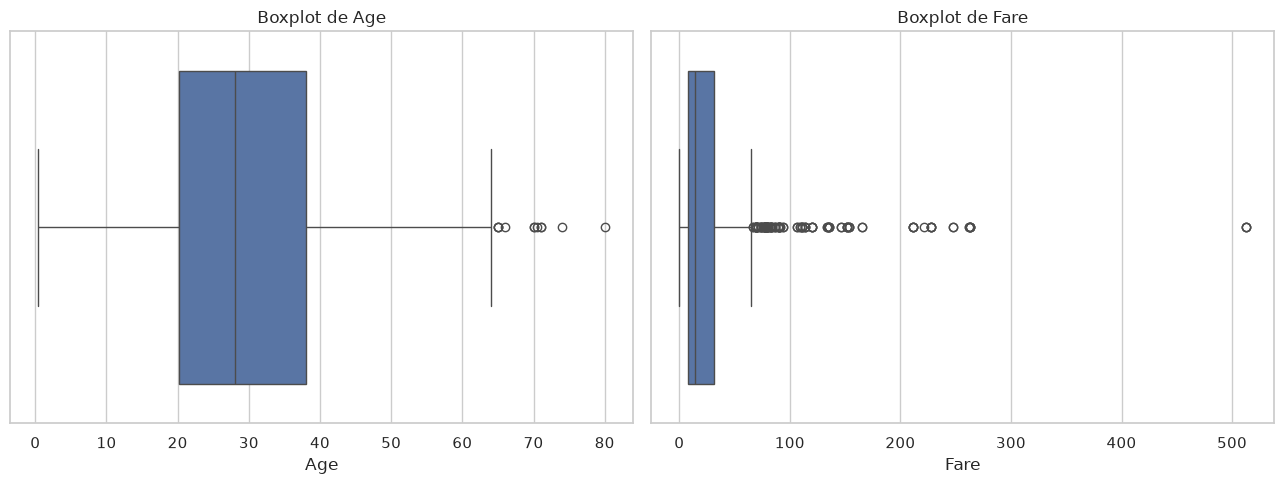

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=titanic_raw, x="Age", ax=axes[0])
axes[0].set_title("Boxplot de Age")

sns.boxplot(data=titanic_raw, x="Fare", ax=axes[1])
axes[1].set_title("Boxplot de Fare")

plt.tight_layout()
plt.show()

# 13. Detección con IQR

Sean:

$$
Q_1=P_{25},
\qquad
Q_3=P_{75}.
$$

El rango intercuartílico es:

$$
IQR=Q_3-Q_1.
$$

Los límites de Tukey son:

$$
L_I=Q_1-1.5IQR,
$$

$$
L_S=Q_3+1.5IQR.
$$

Se marca como potencialmente atípico:

$$
x<L_I
\quad\text{o}\quad
x>L_S.
$$

In [40]:
def detectar_outliers_iqr(serie):
    s = serie.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr

    mascara = (serie < li) | (serie > ls)
    return mascara, li, ls

In [41]:
for variable in ["Age", "Fare"]:
    mask, li, ls = detectar_outliers_iqr(
        titanic_raw[variable]
    )

    print(f"\n{variable}")
    print(f"Límite inferior: {li:.3f}")
    print(f"Límite superior: {ls:.3f}")
    print(f"Potenciales outliers: {mask.sum()}")


Age
Límite inferior: -6.688
Límite superior: 64.812
Potenciales outliers: 11

Fare
Límite inferior: -26.724
Límite superior: 65.634
Potenciales outliers: 116


In [51]:
titanic_raw.loc[detectar_outliers_iqr(titanic_raw["Age"])[0], "Age"]

33    66.000
54    65.000
96    71.000
116   70.500
280   65.000
456   65.000
493   71.000
630   80.000
672   70.000
745   70.000
851   74.000
Name: Age, dtype: float64

In [53]:
titanic_raw.loc[detectar_outliers_iqr(titanic_raw["Age"])[0]]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.000,0,0,C.A. 24579,10.500,NaN,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.000,0,1,113509,61.979,B30,C
96,97,0,1,"Goldschmidt, Mr. George B",male,71.000,0,0,PC 17754,34.654,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.500,0,0,370369,7.750,NaN,Q
280,281,0,3,"Duane, Mr. Frank",male,65.000,0,0,336439,7.750,NaN,Q
456,457,0,1,"Millet, Mr. Francis Davis",male,65.000,0,0,13509,26.550,E38,S
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.000,0,0,PC 17609,49.504,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.000,0,0,27042,30.000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.000,0,0,C.A. 24580,10.500,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.000,1,1,WE/P 5735,71.000,B22,S


In [54]:
titanic_raw.loc[detectar_outliers_iqr(titanic_raw["Fare"])[0]]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.000,3,2,19950,263.000,C23 C25 C27,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.521,B78,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.000,1,0,PC 17604,82.171,NaN,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.000,1,0,PC 17572,76.729,D33,C
...,...,...,...,...,...,...,...,...,...,...,...,...
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.550,NaN,S
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,NaN,1,0,17453,89.104,C92,C
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.000,1,1,36928,164.867,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.550,NaN,S


## 13.1 ¿Las tarifas altas son errores?

No necesariamente.

Podemos revisar el contexto: `Fare` está relacionado con `Pclass`.

In [42]:
mask_fare, _, ls_fare = detectar_outliers_iqr(
    titanic_raw["Fare"]
)

titanic_raw.loc[
    mask_fare,
    ["PassengerId", "Pclass", "Fare", "Cabin"]
].sort_values("Fare", ascending=False).head(15)

,PassengerId,Pclass,Fare,Cabin
679,680,1,512.329,B51 B53 B55
258,259,1,512.329,NaN
737,738,1,512.329,B101
341,342,1,263.000,C23 C25 C27
438,439,1,263.000,C23 C25 C27
88,89,1,263.000,C23 C25 C27
27,28,1,263.000,C23 C25 C27
311,312,1,262.375,B57 B59 B63 B66
742,743,1,262.375,B57 B59 B63 B66
118,119,1,247.521,B58 B60


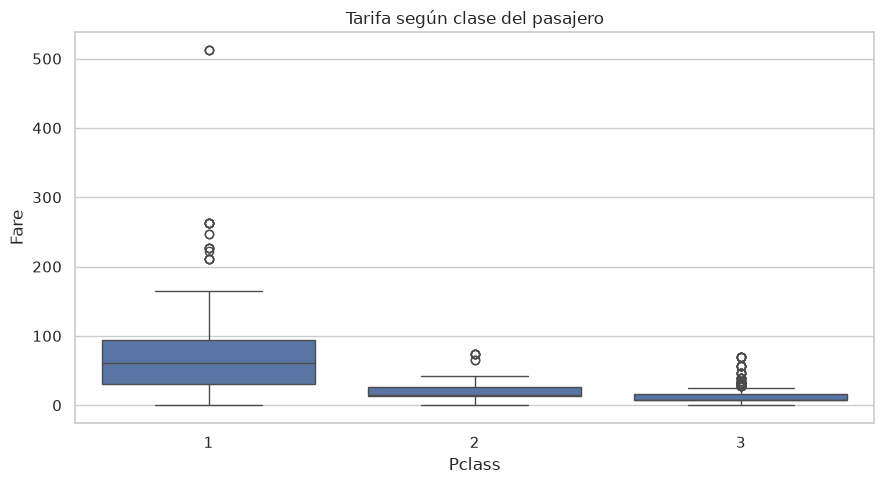

In [43]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=titanic_raw,
    x="Pclass",
    y="Fare"
)
plt.title("Tarifa según clase del pasajero")
plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

Una tarifa extrema puede ser una observación legítima de primera clase.

Eliminarla automáticamente eliminaría información real.

# 14. Regla de las tres desviaciones

El puntaje estandarizado es:

$$
z_i=
\frac{x_i-\bar{x}}{s}.
$$

Una regla frecuente es:

$$
|z_i|>3.
$$

Esta regla es más interpretable cuando la distribución es aproximadamente simétrica.

En distribuciones muy asimétricas, el IQR suele ser más robusto.

In [44]:
fare_no_na = titanic_raw["Fare"].dropna()
z_fare = stats.zscore(fare_no_na)

print(
    "Fare con |z| > 3:",
    (np.abs(z_fare) > 3).sum()
)

print(
    "Fare por IQR:",
    mask_fare.sum()
)

Fare con |z| > 3: 20
Fare por IQR: 116


Los métodos no tienen que coincidir.

Esto muestra que “ser outlier” depende del criterio elegido.

# 15. Estadísticos robustos

Cuando existen extremos es útil comparar:

- media con mediana;
- desviación estándar con IQR.

In [45]:
pd.Series({
    "Media Fare": titanic_raw["Fare"].mean(),
    "Mediana Fare": titanic_raw["Fare"].median(),
    "Desviación Fare": titanic_raw["Fare"].std(),
    "IQR Fare": (
        titanic_raw["Fare"].quantile(0.75)
        - titanic_raw["Fare"].quantile(0.25)
    )
})

Media Fare        32.204
Mediana Fare      14.454
Desviación Fare   49.693
IQR Fare          23.090
dtype: float64

# 16. Tratamiento responsable de outliers

Opciones:

1. conservarlos;
2. corregirlos si hay evidencia de error;
3. eliminarlos si son inválidos;
4. recortar extremos;
5. transformar la variable;
6. usar métodos robustos.

Nunca debería aplicarse:

```python
df = df[~mask_outlier]
```

como una regla automática.

## 16.1 Recorte (*clipping*)

$$
x_i^*
=
\min\{
\max(x_i,L_I),
L_S
\}.
$$

In [46]:
_, li_fare, ls_fare = detectar_outliers_iqr(
    titanic_raw["Fare"]
)

fare_clip = titanic_raw["Fare"].clip(
    lower=li_fare,
    upper=ls_fare
)

pd.DataFrame({
    "Fare_original": titanic_raw["Fare"],
    "Fare_clip": fare_clip
}).describe()

,Fare_original,Fare_clip
count,891.000,891.000
mean,32.204,24.047
std,49.693,20.482
min,0.000,0.000
25%,7.910,7.910
50%,14.454,14.454
75%,31.000,31.000
max,512.329,65.634


El recorte modifica datos válidos. Para `Fare`, una transformación logarítmica será una alternativa más interpretable.

# PARTE III. NORMALIDAD Y TRANSFORMACIONES

# 17. Distribución normal

Una variable normal se escribe:

$$
X\sim N(\mu,\sigma^2).
$$

Su densidad es:

$$
f(x)
=
\frac{1}{\sigma\sqrt{2\pi}}
\exp\left(
-\frac{(x-\mu)^2}{2\sigma^2}
\right).
$$

Características:

- simetría;
- forma de campana;
- centro en \(\mu\);
- dispersión controlada por \(\sigma\).

## 17.1 Precisión conceptual

No todos los modelos requieren que cada predictor sea normal.

Además:

> `StandardScaler` no “normaliza” una distribución en el sentido probabilístico.

Estandarizar cambia centro y escala, pero no convierte automáticamente una variable sesgada en gaussiana.

# 18. Gráfico Q-Q

El gráfico Q-Q compara:

$$
\text{cuantiles observados}
$$

con

$$
\text{cuantiles teóricos normales}.
$$

Si la distribución se aproxima a una normal, los puntos siguen aproximadamente una línea recta.

- curvatura: asimetría;
- desviaciones en extremos: diferencias en colas;
- puntos aislados: posibles observaciones extremas.

In [ ]:
edad = titanic_raw["Age"].dropna()
fare = titanic_raw["Fare"].dropna()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.histplot(edad, bins=25, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Histograma: Age")

stats.probplot(
    edad,
    dist="norm",
    plot=axes[0, 1]
)
axes[0, 1].set_title("Q-Q plot: Age")

sns.histplot(fare, bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Histograma: Fare")

stats.probplot(
    fare,
    dist="norm",
    plot=axes[1, 1]
)
axes[1, 1].set_title("Q-Q plot: Fare")

plt.tight_layout()
plt.show()

`Fare` muestra fuerte asimetría positiva. `Age` es más simétrica, aunque eso no implica normalidad perfecta.

# 19. Shapiro-Wilk

Formulamos:

$$
H_0:\text{los datos son compatibles con normalidad}
$$

$$
H_1:\text{los datos no siguen una normal}.
$$

Con nivel \(\alpha\):

- \(p<\alpha\): rechazar \(H_0\);
- \(p\geq\alpha\): no rechazar \(H_0\).

En muestras grandes, pequeñas desviaciones pueden producir p-valores muy pequeños. Por eso conviene combinar prueba formal y gráfico Q-Q.

In [ ]:
for nombre, serie in {
    "Age": edad,
    "Fare": fare
}.items():
    W, p = stats.shapiro(serie)

    print(
        f"{nombre}: "
        f"W={W:.4f}, "
        f"p={p:.6g}"
    )

# 20. Transformación logarítmica

Para una variable positiva:

$$
Y=\log(X).
$$

Si puede contener cero:

$$
Y=\log(1+X).
$$

En Python:

```python
np.log1p(X)
```

La transformación logarítmica:

- comprime valores grandes;
- reduce asimetría positiva;
- cambia una escala absoluta por una más relativa;
- puede ayudar a estabilizar variabilidad.

No garantiza normalidad.

In [ ]:
fare_log = np.log1p(titanic_raw["Fare"])

print(
    "Asimetría original:",
    titanic_raw["Fare"].skew()
)
print(
    "Asimetría log1p:",
    fare_log.skew()
)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.histplot(
    titanic_raw["Fare"],
    bins=30,
    kde=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Fare original")

stats.probplot(
    titanic_raw["Fare"].dropna(),
    dist="norm",
    plot=axes[0, 1]
)
axes[0, 1].set_title("Q-Q: Fare original")

sns.histplot(
    fare_log,
    bins=30,
    kde=True,
    ax=axes[1, 0]
)
axes[1, 0].set_title("log(1 + Fare)")

stats.probplot(
    fare_log.dropna(),
    dist="norm",
    plot=axes[1, 1]
)
axes[1, 1].set_title("Q-Q: log(1 + Fare)")

plt.tight_layout()
plt.show()

# 21. Transformaciones de potencia

## Box-Cox

Para \(x>0\):

$$
T_\lambda(x)
=
\begin{cases}
\dfrac{x^\lambda-1}{\lambda},
&\lambda\neq0,\\[6pt]
\log(x),
&\lambda=0.
\end{cases}
$$

## Yeo-Johnson

Extiende la idea a datos que pueden incluir cero y valores negativos.

`PowerTransformer` puede estimar automáticamente el parámetro de transformación.

In [ ]:
power = PowerTransformer(
    method="yeo-johnson",
    standardize=False
)

fare_yj = power.fit_transform(
    titanic_raw[["Fare"]]
).ravel()

print("Lambda:", power.lambdas_[0])
print("Skew original:", titanic_raw["Fare"].skew())
print("Skew Yeo-Johnson:", pd.Series(fare_yj).skew())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(
    titanic_raw["Fare"],
    bins=30,
    ax=axes[0]
)
axes[0].set_title("Fare original")

sns.histplot(
    fare_yj,
    bins=30,
    ax=axes[1]
)
axes[1].set_title("Fare con Yeo-Johnson")

plt.tight_layout()
plt.show()

# 22. Transformación de forma vs. escalamiento

## Cambiar forma

- logaritmo;
- Box-Cox;
- Yeo-Johnson.

Puede modificar asimetría.

## Cambiar escala

- Min-Max;
- StandardScaler.

Una transformación lineal cambia centro y escala, pero conserva la forma esencial.

# 23. Normalización Min-Max

$$
x_i^*
=
\frac{x_i-x_{\min}}
{x_{\max}-x_{\min}}.
$$

Sobre los datos usados para ajustar el transformador:

$$
0\leq x_i^*\leq1.
$$

Es sensible a extremos porque depende de mínimo y máximo.

In [ ]:
minmax = MinMaxScaler()

age_minmax = minmax.fit_transform(
    edad.to_numpy().reshape(-1, 1)
).ravel()

print("Mínimo:", age_minmax.min())
print("Máximo:", age_minmax.max())

# 24. Estandarización

$$
z_i
=
\frac{x_i-\bar{x}}{s}.
$$

Después de estandarizar los datos usados para el ajuste:

$$
\bar z\approx0,
\qquad
s_z\approx1.
$$

### Importante

Estandarizar **no hace normal** una variable.

In [ ]:
std_scaler = StandardScaler()

fare_std = std_scaler.fit_transform(
    fare.to_numpy().reshape(-1, 1)
).ravel()

print("Media:", fare_std.mean())
print("Desviación:", fare_std.std(ddof=0))
print("Skew original:", fare.skew())
print("Skew estandarizada:", pd.Series(fare_std).skew())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(fare, bins=30, ax=axes[0])
axes[0].set_title("Fare original")

sns.histplot(fare_std, bins=30, ax=axes[1])
axes[1].set_title("Fare estandarizada")

plt.tight_layout()
plt.show()

La distribución conserva su asimetría general: cambió la escala, no la naturaleza de la forma.

# PARTE IV. VARIABLES CATEGÓRICAS Y DUMIFICACIÓN

# 25. ¿Por qué codificar categorías?

Muchos algoritmos trabajan con una matriz numérica:

$$
X\in\mathbb{R}^{n\times p}.
$$

La codificación debe respetar el significado:

- ordinal: puede representarse con un orden;
- nominal: no debemos inventar una jerarquía.

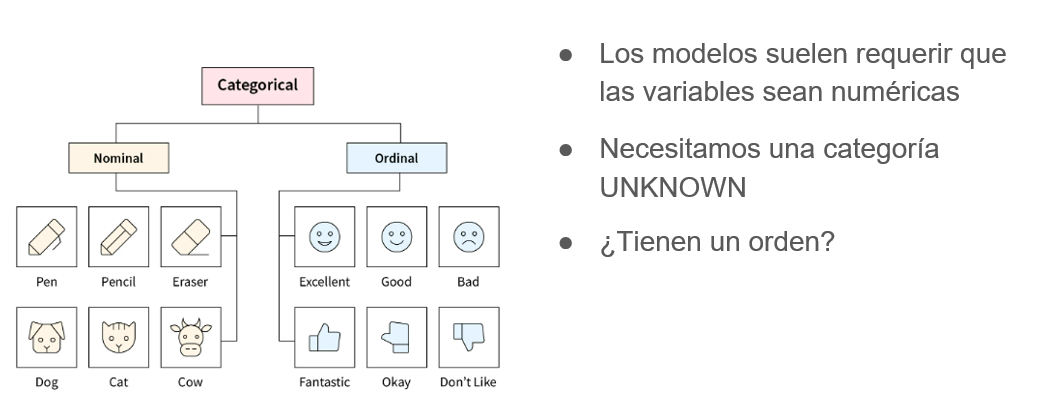

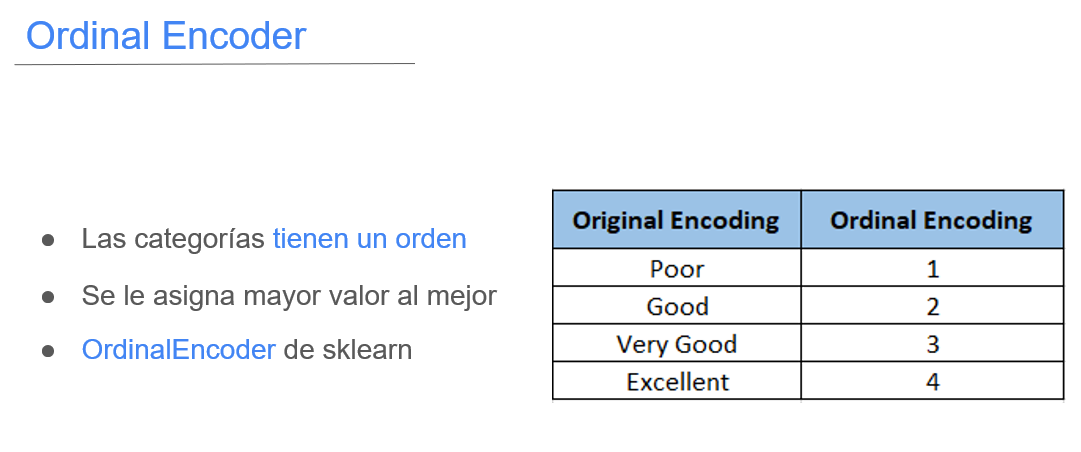

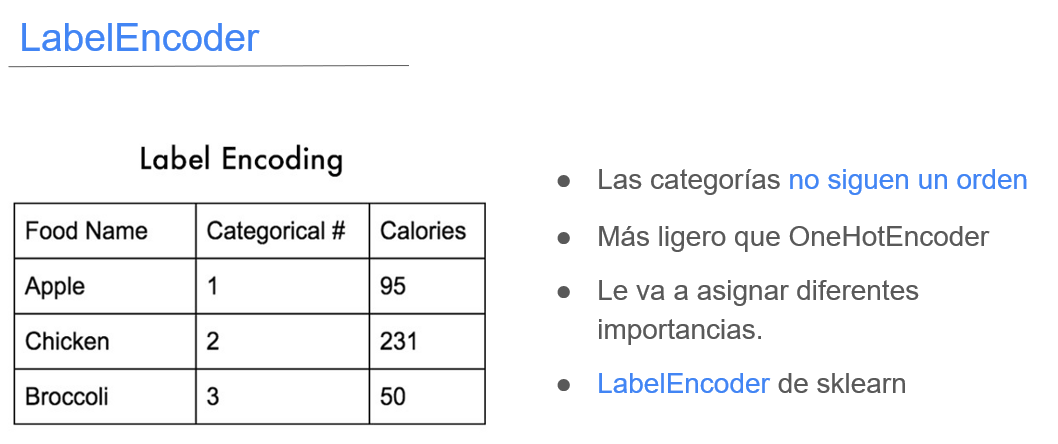

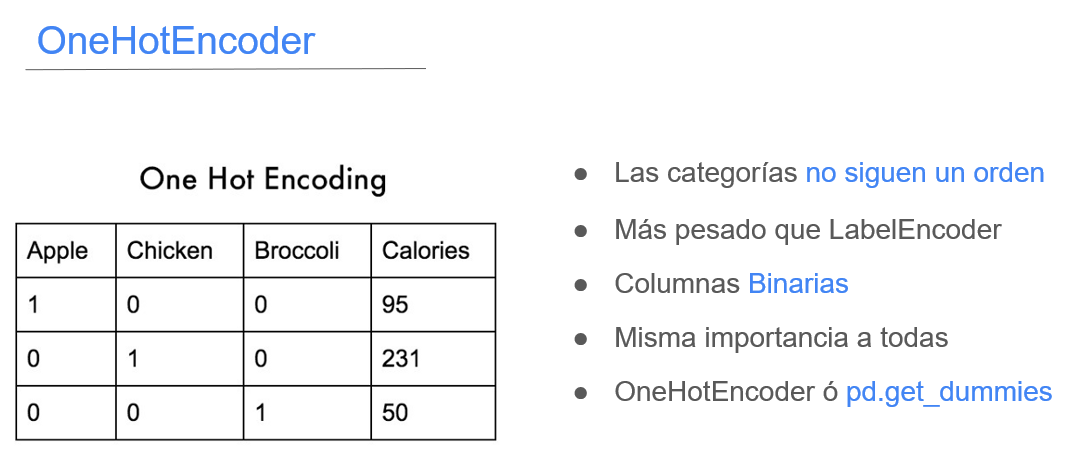

# 26. Nominales vs ordinales

## Nominal

```text
C, Q, S
```

No existe una relación:

$$
C<Q<S.
$$

## Ordinal

Para calidad exterior:

$$
Fa<TA<Gd<Ex.
$$

In [ ]:
print("ExterQual:")
print(viviendas_raw["ExterQual"].value_counts())

print("\nSaleCondition:")
print(viviendas_raw["SaleCondition"].value_counts())

# 27. Codificación ordinal

Definimos explícitamente el significado:

$$
f(c)=
\begin{cases}
1,&c=Fa\\
2,&c=TA\\
3,&c=Gd\\
4,&c=Ex.
\end{cases}
$$

In [ ]:
orden_exterqual = {
    "Fa": 1,
    "TA": 2,
    "Gd": 3,
    "Ex": 4
}

ejemplo_ord = viviendas_raw[["ExterQual"]].copy()

ejemplo_ord["ExterQual_ord"] = (
    ejemplo_ord["ExterQual"]
    .map(orden_exterqual)
)

ejemplo_ord.head(10)

## 27.1 OrdinalEncoder con orden explícito

In [ ]:
ord_encoder = OrdinalEncoder(
    categories=[["Fa", "TA", "Gd", "Ex"]],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

exter_encoded = ord_encoder.fit_transform(
    viviendas_raw[["ExterQual"]]
)

pd.Series(
    exter_encoded.ravel()
).value_counts().sort_index()

En variables ordinales debemos definir el orden semántico. No conviene confiar ciegamente en un orden automático de strings.

# 28. LabelEncoder

`LabelEncoder` convierte etiquetas en enteros y está pensado principalmente para la variable objetivo \(y\).

Para predictores nominales puede crear una jerarquía artificial.

Por ejemplo:

```text
C -> 0
Q -> 1
S -> 2
```

no significa que \(S\) sea “el doble” de \(Q\).

In [ ]:
le = LabelEncoder()

y_demo = pd.Series([
    "No sobrevivió",
    "Sobrevivió",
    "No sobrevivió",
    "Sobrevivió"
])

pd.DataFrame({
    "original": y_demo,
    "codificado": le.fit_transform(y_demo)
})

# 29. One-Hot Encoding o dumificación

Para una categoría \(C\) con niveles \(c_1,\ldots,c_K\), creamos:

$$
D_j=I(C=c_j).
$$

Cada dummy es binaria.

Esto evita imponer un orden inexistente.

## 29.1 pd.get_dummies

In [ ]:
dummies_embarked = pd.get_dummies(
    titanic_raw["Embarked"],
    prefix="Embarked",
    dummy_na=True,
    dtype=int
)

dummies_embarked.head()

## 29.2 Varias variables

In [ ]:
dummies_titanic = pd.get_dummies(
    titanic_raw[
        ["Sex", "Embarked", "Pclass"]
    ].astype({"Pclass": "string"}),
    dummy_na=True,
    dtype=int
)

dummies_titanic.head()

# 30. OneHotEncoder

Para flujos profesionales ofrece:

- aprendizaje de categorías con entrenamiento;
- manejo de categorías desconocidas;
- integración con `Pipeline`;
- integración con `ColumnTransformer`.

In [ ]:
onehot = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_cat = titanic_raw[
    ["Sex", "Embarked"]
].fillna("Unknown")

X_cat_enc = onehot.fit_transform(X_cat)

pd.DataFrame(
    X_cat_enc,
    columns=onehot.get_feature_names_out()
).head()

## 30.1 Categorías nuevas

Si en producción aparece una categoría no vista, `handle_unknown="ignore"` evita que el transformador falle.

In [ ]:
nuevo = pd.DataFrame({
    "Sex": ["female"],
    "Embarked": ["X"]
})

onehot.transform(nuevo)

# 31. La “trampa de las dummies”

Con \(K\) dummies completas:

$$
D_1+D_2+\cdots+D_K=1.
$$

En modelos lineales con intercepto puede existir dependencia lineal perfecta.

Puede usarse:

```python
OneHotEncoder(drop="first")
```

cuando el modelo lo requiere.

En modelos basados en árboles no suele ser necesario.

# PARTE V. DEPURACIÓN ESTRUCTURAL Y FLUJO PROFESIONAL

# 32. Alta cardinalidad

Una variable categórica posee alta cardinalidad cuando tiene muchos niveles.

En Titanic:

- `Name`;
- `Ticket`;
- `Cabin`.

Dumificar directamente puede producir cientos de variables.

In [ ]:
for col in ["Name", "Ticket", "Cabin"]:
    print(
        f"{col}:",
        titanic_raw[col].nunique(dropna=True)
    )

## 32.1 Extraer información útil

En lugar de dumificar cada nombre, podemos extraer el título.

In [ ]:
titanic["Title"] = (
    titanic_raw["Name"]
    .str.extract(r",\s*([^.]*)\.")
    [0]
    .str.strip()
)

titanic["Title"].value_counts().head(12)

# 33. Variables con poca variabilidad

Una variable cuantitativa constante cumple:

$$
\operatorname{Var}(X)=0.
$$

Una categórica con una sola categoría tampoco distingue observaciones.

Sin embargo, poca varianza **no implica automáticamente poca utilidad**. La escala y el problema importan.

In [ ]:
for col in titanic_raw.select_dtypes(include="object").columns:
    print(
        f"{col:10s}: "
        f"{titanic_raw[col].nunique(dropna=True)} categorías"
    )

# 34. Correlación y redundancia

El coeficiente de Pearson es:

$$
r_{XY}
=
\frac{
\sum_{i=1}^{n}
(x_i-\bar{x})(y_i-\bar{y})
}{
\sqrt{
\sum_{i=1}^{n}(x_i-\bar{x})^2
\sum_{i=1}^{n}(y_i-\bar{y})^2
}
}.
$$

Una correlación alta puede sugerir redundancia, pero:

$$
\text{correlación}\neq\text{causalidad}.
$$

In [ ]:
matriz_corr = (
    titanic_raw
    .select_dtypes(include="number")
    .corr()
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Matriz de correlaciones — Titanic")
plt.tight_layout()
plt.show()

# 35. Regla fundamental: dividir antes de ajustar transformadores

Sea:

$$
D=D_{\text{train}}\cup D_{\text{test}}.
$$

La mediana, media, mínimo, máximo, categorías y parámetros de transformación deben aprenderse únicamente con:

$$
D_{\text{train}}.
$$

Luego se transforman ambos conjuntos con los mismos parámetros.

# 36. Data leakage

Hay fuga de información cuando el test influye en entrenamiento.

## Incorrecto

```python
X = scaler.fit_transform(X)
X_train, X_test = train_test_split(X)
```

## Correcto

```python
X_train, X_test = train_test_split(X)

scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
```

# 37. Preparación de Titanic para un modelo

Variables numéricas:

- `Age`;
- `Fare`;
- `SibSp`;
- `Parch`.

Variables categóricas:

- `Pclass`;
- `Sex`;
- `Embarked`.

Objetivo:

- `Survived`.

In [ ]:
features = [
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "Pclass",
    "Sex",
    "Embarked"
]

X = titanic_raw[features].copy()
y = titanic_raw["Survived"].copy()

X["Pclass"] = X["Pclass"].astype(str)

X.head()

## 37.1 Split estratificado

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nProporciones train:")
print(y_train.value_counts(normalize=True))

print("\nProporciones test:")
print(y_test.value_counts(normalize=True))

# 38. Pipeline y ColumnTransformer

## Numéricas

1. imputación por mediana;
2. StandardScaler.

## Categóricas

1. imputación por moda;
2. One-Hot Encoding.

In [ ]:
numeric_features = [
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked"
]

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

preprocessor

## 38.1 Ajustar únicamente con train

In [ ]:
X_train_preparado = preprocessor.fit_transform(
    X_train
)

X_test_preparado = preprocessor.transform(
    X_test
)

print("Train transformado:", X_train_preparado.shape)
print("Test transformado:", X_test_preparado.shape)

## 38.2 Variables resultantes

In [ ]:
preprocessor.get_feature_names_out()

Este único objeto garantiza que el mismo proceso se aplique a entrenamiento y prueba.

# 39. Caso complementario: viviendas

`ExterQual` es ordinal.

`SaleCondition` es nominal.

`MSSubClass` es un código categórico aunque esté almacenado como entero.

In [ ]:
casa_cat = viviendas_raw[
    [
        "ExterQual",
        "ExterCond",
        "SaleCondition",
        "MSSubClass",
        "SalePrice"
    ]
].copy()

casa_cat.head()

## 39.1 MSSubClass como categoría

In [ ]:
casa_cat["MSSubClass_cat"] = (
    casa_cat["MSSubClass"]
    .astype(str)
)

print(
    "Número de categorías:",
    casa_cat["MSSubClass_cat"].nunique()
)

## 39.2 ExterQual ordinal

In [ ]:
orden_calidad = {
    "Fa": 1,
    "TA": 2,
    "Gd": 3,
    "Ex": 4
}

casa_cat["ExterQual_ord"] = (
    casa_cat["ExterQual"]
    .map(orden_calidad)
)

casa_cat[
    ["ExterQual", "ExterQual_ord"]
].head()

## 39.3 SaleCondition dummy

In [ ]:
sale_dummies = pd.get_dummies(
    casa_cat["SaleCondition"],
    prefix="SaleCondition",
    dtype=int
)

sale_dummies.head()

## 39.4 Calidad exterior y precio

In [ ]:
casa_cat.groupby(
    "ExterQual"
)["SalePrice"].agg(
    cantidad="count",
    mediana="median",
    media="mean"
).reindex(
    ["Fa", "TA", "Gd", "Ex"]
)

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=casa_cat,
    x="ExterQual",
    y="SalePrice",
    order=["Fa", "TA", "Gd", "Ex"]
)

plt.title("Precio de venta según calidad exterior")
plt.xlabel("Calidad exterior")
plt.ylabel("SalePrice")
plt.tight_layout()
plt.show()

# 40. Target / Mean Encoding: idea y precaución

Puede sustituirse una categoría por:

$$
TE(c)=E[Y\mid X=c].
$$

Por ejemplo, mediana de precio por `MSSubClass`.

Es potente, pero si se calcula con todo el dataset puede introducir **data leakage**.

Debe ajustarse solamente con entrenamiento y, en aplicaciones serias, suele utilizar regularización o validación cruzada.

In [ ]:
mediana_precio_por_clase = (
    viviendas_raw
    .groupby("MSSubClass")["SalePrice"]
    .median()
)

mediana_precio_por_clase.head()

# 44. Guía de decisión rápida

| Problema | Diagnóstico | Acciones posibles |
|---|---|---|
| Faltantes numéricos | porcentaje, patrón, distribución | mediana, media, KNN, modelo, eliminar |
| Faltantes categóricos | frecuencia y contexto | moda, `Unknown`, eliminar |
| Outlier válido | boxplot, IQR, contexto | conservar, transformar, método robusto |
| Outlier inválido | regla de negocio | corregir o eliminar |
| Asimetría | histograma, skew, Q-Q | log, Box-Cox, Yeo-Johnson |
| Escalas distintas | comparación de magnitudes | Min-Max, StandardScaler |
| Categórica ordinal | existe orden | Ordinal Encoding |
| Categórica nominal | no existe orden | One-Hot |
| Alta cardinalidad | muchos niveles | ingeniería, agrupación |
| Identificador | casi todos únicos | excluir o extraer información |

# 45. Errores frecuentes

1. Eliminar todos los outliers.
2. Imputar todos los nulos con media.
3. Afirmar que estandarizar produce normalidad.
4. Usar enteros para categorías nominales como si fueran magnitudes.
5. Ajustar escaladores antes del split.
6. Dumificar identificadores de alta cardinalidad.
7. No conservar una copia bruta.
8. No documentar decisiones.

# 46. Checklist profesional

## Comprensión
- [ ] Unidad de observación clara.
- [ ] Significado de cada variable.
- [ ] Identificadores separados de magnitudes.

## Calidad
- [ ] Nulos revisados.
- [ ] Duplicados revisados.
- [ ] Reglas de validez revisadas.
- [ ] Categorías consistentes.

## Distribuciones
- [ ] Histogramas.
- [ ] Boxplots.
- [ ] Q-Q plots cuando corresponde.
- [ ] Outliers investigados.

## Transformación
- [ ] Forma vs escala diferenciadas.
- [ ] Nominal vs ordinal diferenciadas.
- [ ] Alta cardinalidad revisada.

## Reproducibilidad
- [ ] Split antes de ajustar.
- [ ] Imputadores ajustados con train.
- [ ] Escaladores ajustados con train.
- [ ] Pipeline cuando corresponde.

# 47. Conclusión

La preparación de datos debe conservar información relevante y reducir errores sin introducir supuestos innecesarios.

Dos ideas esenciales:

$$
\boxed{\text{limpiar}\neq\text{borrar}}
$$

$$
\boxed{\text{estandarizar}\neq\text{hacer normal}}
$$

Una buena preparación combina:

$$
\text{comprensión}
+
\text{diagnóstico}
+
\text{teoría}
+
\text{código reproducible}
+
\text{justificación}.
$$